In [ ]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from collections import Counter

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 10,
    'axes.linewidth'   : 0.8,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.spines.left' : False,
    'savefig.dpi'      : 600,
    'savefig.bbox'     : 'tight',
    'savefig.facecolor': 'white',
})

PAPER_FILE = "C:/Users/PC/Downloads/genomeer/datasets/paper_combined_final.jsonl"
FORUM_FILE = "C:/Users/PC/Downloads/genomeer/datasets/Forum_combined.jsonl"
GITHUB_FILE = "C:/Users/PC/Downloads/genomeer/github.jsonl" 

def load_jsonl(path):
    rows = []
    if not os.path.exists(path):
        print(f"[WARN] Not found: {path}")
        return rows
    with open(path, encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

paper_rows = load_jsonl(PAPER_FILE)
forum_rows = load_jsonl(FORUM_FILE)
github_rows = load_jsonl(GITHUB_FILE) # Chargement de GitHub

all_rows = paper_rows + forum_rows + github_rows # Ajout au total

print(f"Paper records  : {len(paper_rows):,}")
print(f"Forum records  : {len(forum_rows):,}")
print(f"GitHub records : {len(github_rows):,}")
print(f"Total          : {len(all_rows):,}")

Paper records  : 31,636
Forum records  : 10,253
GitHub records : 2,040
Total          : 43,929


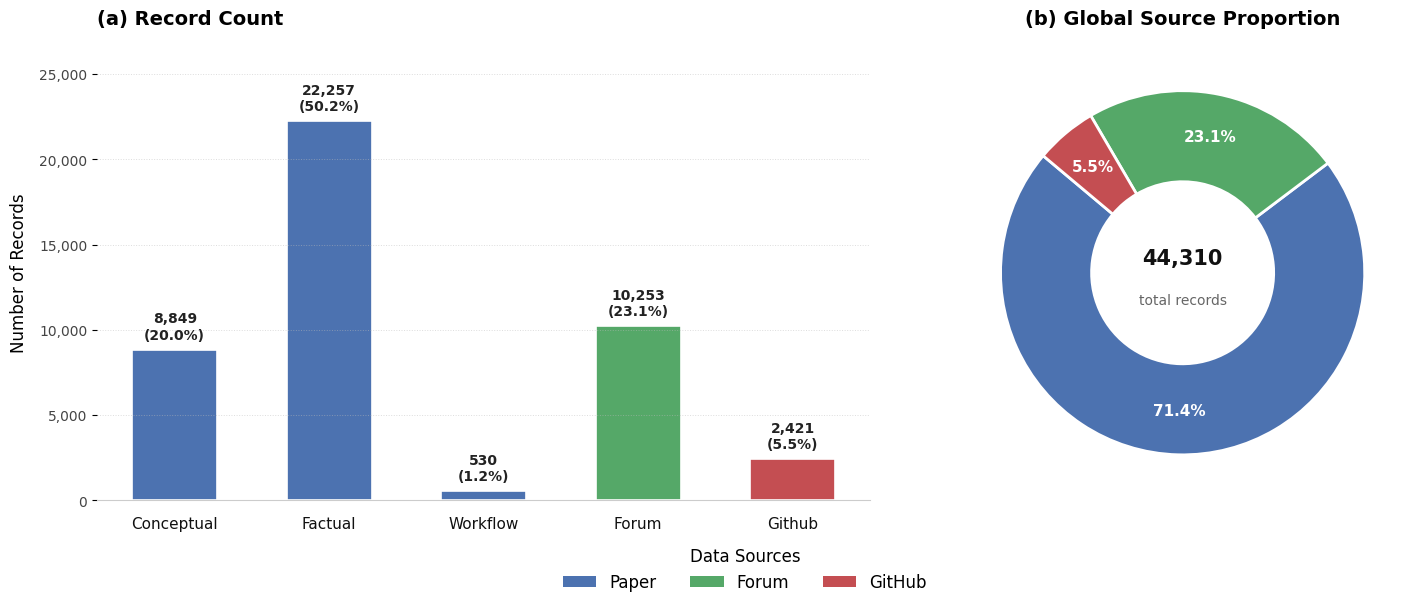

Répartition globale par Source :
- Paper  : 31,636 (71.4%)
- Forum  : 10,253 (23.1%)
- GitHub : 2,421 (5.5%)


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from collections import Counter

# ✅ DPI 600
plt.rcParams.update({
    'savefig.dpi': 600
})

# --- 1. Fonction de classification ---
def get_dataset_slice(row, source):
    if source == "paper":
        t = str(row.get("type", "")).strip().lower()
        if not t:
            if "instruction" in row or "output" in row:
                return "Paper - Conceptual"
            return "Paper - Conceptual"

        if "workflow" in t:
            return "Paper - Workflow"
        elif "factual" in t:
            return "Paper - Factual"
        elif "conceptual" in t:
            return "Paper - Conceptual"
        else:
            return "Paper - Conceptual"

    elif source == "forum":
        return "Forum"
    elif source == "github":
        return "GitHub"

# --- 2. Comptage des données ---
counts = Counter()

for r in paper_rows:
    counts[get_dataset_slice(r, "paper")] += 1
for r in forum_rows:
    counts[get_dataset_slice(r, "forum")] += 1
for r in github_rows:
    counts[get_dataset_slice(r, "github")] += 1

# Données pour le Diagramme en Barres (5 colonnes)
bar_labels_full = ["Paper - Conceptual", "Paper - Factual", "Paper - Workflow", "Forum", "GitHub"]
bar_vals = [counts[l] for l in bar_labels_full]
total_records = sum(bar_vals)

# Données pour le Pie Chart (3 parts : Paper global, Forum, GitHub)
paper_total = counts["Paper - Conceptual"] + counts["Paper - Factual"] + counts["Paper - Workflow"]
pie_vals = [paper_total, counts["Forum"], counts["GitHub"]]

# --- 3. Couleurs ---
SOURCE_COLORS = {
    "Paper": "#4C72B0",
    "Forum": "#55A868",
    "GitHub": "#C44E52"
}

bar_colors = [
    SOURCE_COLORS["Paper"], SOURCE_COLORS["Paper"], SOURCE_COLORS["Paper"],
    SOURCE_COLORS["Forum"], SOURCE_COLORS["GitHub"]
]

pie_colors = [SOURCE_COLORS["Paper"], SOURCE_COLORS["Forum"], SOURCE_COLORS["GitHub"]]

# --- 4. Création de la figure ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1.3, 1]})
fig.patch.set_facecolor('white')

# (a) Bar chart
ax = axes[0]
ax.set_facecolor('white')

clean_x_labels = ["Conceptual", "Factual", "Workflow", "Forum", "Github"]

bars = ax.bar(clean_x_labels, bar_vals, color=bar_colors, width=0.55, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, bar_vals):
    pct = val / total_records * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + total_records * 0.01,
            f'{val:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#222222')

ax.set_ylabel('Number of Records', labelpad=8, fontsize=12)
ax.set_title('(a) Record Count', fontsize=14, fontweight='bold', pad=15, loc='left')
ax.set_ylim(0, max(bar_vals) * 1.20)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', which='major', labelsize=11, labelcolor='#111111', pad=8, bottom=False)
ax.tick_params(axis='y', which='major', labelsize=10, labelcolor='#444444')
ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.5, color='#BBBBBB')
ax.spines['bottom'].set_color('#CCCCCC')

# (b) Pie chart
ax2 = axes[1]

wedges, _, autotexts = ax2.pie(
    pie_vals,
    labels=None,
    colors=pie_colors,
    autopct='%1.1f%%',
    pctdistance=0.76,
    startangle=140,
    wedgeprops=dict(width=0.50, edgecolor='white', linewidth=2.0),
)

for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
    at.set_fontsize(11)

ax2.text(0, 0.08, f'{total_records:,}', ha='center', va='center',
         fontsize=15, fontweight='bold', color='#111111')
ax2.text(0, -0.15, 'total records', ha='center', va='center',
         fontsize=10, color='#666666')

ax2.set_title('(b) Global Source Proportion', fontsize=14, fontweight='bold', pad=15)

# --- 5. Légende ---
legend_elements = [
    mpatches.Patch(facecolor=SOURCE_COLORS['Paper'], label='Paper'),
    mpatches.Patch(facecolor=SOURCE_COLORS['Forum'], label='Forum'),
    mpatches.Patch(facecolor=SOURCE_COLORS['GitHub'], label='GitHub')
]

fig.legend(handles=legend_elements,
           title="Data Sources", title_fontsize=12,
           loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=3, frameon=False, fontsize=12)

# --- 6. Affichage ---
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

# Bilan
print("Répartition globale par Source :")
print(f"- Paper  : {paper_total:,} ({(paper_total/total_records)*100:.1f}%)")
print(f"- Forum  : {counts['Forum']:,} ({(counts['Forum']/total_records)*100:.1f}%)")
print(f"- GitHub : {counts['GitHub']:,} ({(counts['GitHub']/total_records)*100:.1f}%)")

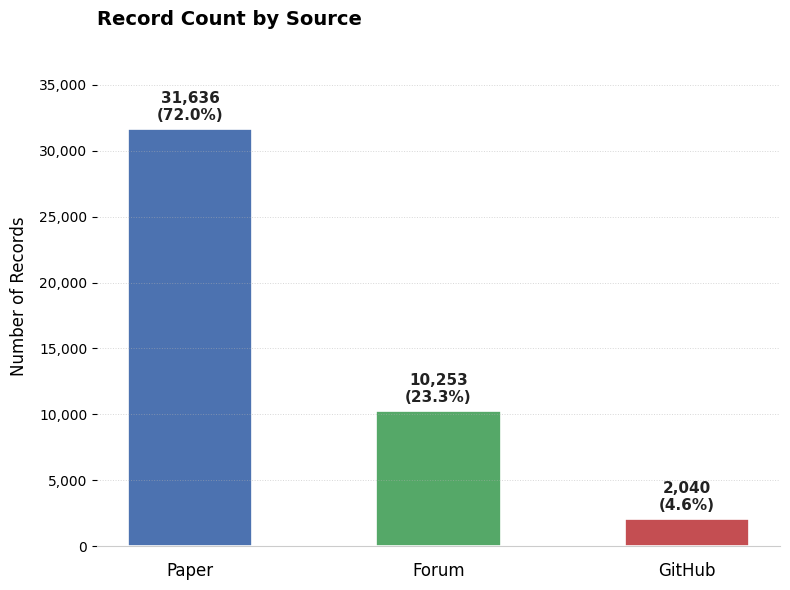

Répartition globale par Source :
- Paper  : 31,636 (72.0%)
- Forum  : 10,253 (23.3%)
- GitHub : 2,040 (4.6%)


In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# DPI
plt.rcParams.update({
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white'
})

# --- 1. Comptage des données ---
from collections import Counter
counts = Counter()

for r in paper_rows:
    counts["Paper"] += 1
for r in forum_rows:
    counts["Forum"] += 1
for r in github_rows:
    counts["GitHub"] += 1

bar_labels = ["Paper", "Forum", "GitHub"]
bar_vals = [counts[l] for l in bar_labels]
total_records = sum(bar_vals)

# --- 2. Couleurs ---
SOURCE_COLORS = {
    "Paper": "#4C72B0",
    "Forum": "#55A868",
    "GitHub": "#C44E52"
}

bar_colors = [SOURCE_COLORS[l] for l in bar_labels]

# --- 3. Figure (une seule axe) ---
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.bar(bar_labels, bar_vals, color=bar_colors, width=0.50, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, bar_vals):
    pct = val / total_records * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total_records * 0.01,
            f'{val:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#222222')

ax.set_ylabel('Number of Records', labelpad=8, fontsize=12)
ax.set_title('Record Count by Source', fontsize=14, fontweight='bold', pad=15, loc='left')
ax.set_ylim(0, max(bar_vals) * 1.20)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', labelsize=12, pad=8, bottom=False)
ax.tick_params(axis='y', labelsize=10)
ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.5)
ax.spines['bottom'].set_color('#CCCCCC')

# --- Sauvegarde 600 DPI ---
plt.tight_layout()
plt.savefig('C:/Users/PC/Downloads/genomeer/images_VF/chart_output.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

# Bilan
print("Répartition globale par Source :")
for label in bar_labels:
    print(f"- {label:<7}: {counts[label]:,} ({(counts[label]/total_records)*100:.1f}%)")

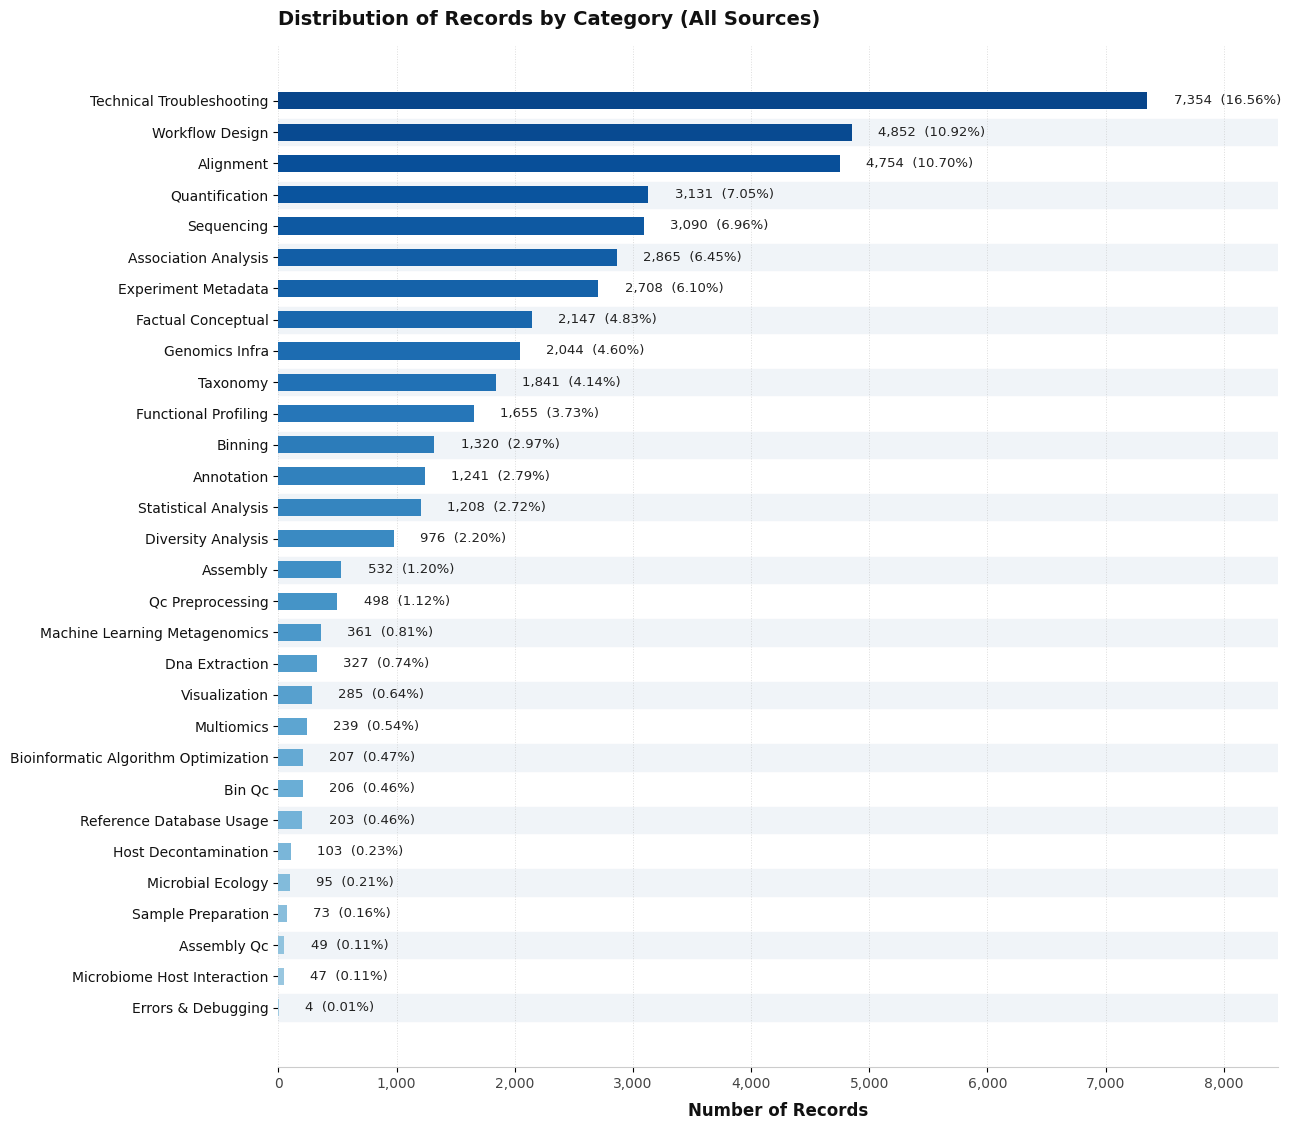

Total categories visualisées : 30
Total records comptabilisés  : 44,415


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from collections import Counter

# --- 1. Fusion des catégories similaires ---
CATEGORY_MERGE = {
    # On a retiré "pipeline_design" pour éviter le double calcul du workflow !
   # "errors_&_debugging"            : "technical_troubleshooting",
    "machine_learning"              : "machine_learning_metagenomics",
     "pipeline_design"               : "workflow_design",
}

# --- 2. Fonction d'extraction de la catégorie ---
def get_category(row, source):
    if source == "paper":
        # Pour le paper, on calcule le workflow avec le "type" (calcul exact)
        t = str(row.get("type", "")).strip().lower()
        if t == "workflow":
            return "workflow_design"
        
        c = str(row.get("category", "")).strip().lower()
        return CATEGORY_MERGE.get(c, c)
        
    elif source == "github":
        # GitHub peut avoir la catégorie dans metadata ou à la racine
        meta = row.get("metadata", {})
        c = meta.get("category", row.get("category", "")) if isinstance(meta, dict) else row.get("category", "")
        c = str(c).strip().lower()
        return CATEGORY_MERGE.get(c, c)
        
    else: 
        # Forum
        meta = row.get("metadata", {})
        c = meta.get("category", "") if isinstance(meta, dict) else ""
        c = str(c).strip().lower()
        return CATEGORY_MERGE.get(c, c)

cat_counter = Counter()

# --- 3. Comptage sur les 3 datasets ---
for r in paper_rows:
    c = get_category(r, "paper")
    if c: cat_counter[c] += 1
        
for r in forum_rows:
    c = get_category(r, "forum")
    if c: cat_counter[c] += 1
        
for r in github_rows:
    c = get_category(r, "github")
    if c: cat_counter[c] += 1

# Suppression des catégories qui sont en fait des "Types" généraux
# ATTENTION : J'ai retiré le .pop("factual_conceptual") pour qu'il s'affiche bien !
cat_counter.pop("factual", None)
cat_counter.pop("conceptual", None)

# Tri des catégories de la plus fréquente à la moins fréquente
cat_sorted  = cat_counter.most_common()
cat_labels  = [c.replace("_", " ").title() for c, _ in cat_sorted]
cat_values  = [v for _, v in cat_sorted]
n           = len(cat_sorted)
total_all   = sum(cat_values)

# Création d'un dégradé de couleur bleu élégant pour les barres horizontales
cmap   = plt.cm.Blues
colors = [cmap(0.35 + 0.55 * (n - i) / max(n-1, 1)) for i in range(n)]

# --- 4. Création de la figure ---
# La hauteur s'adapte automatiquement au nombre de catégories trouvées
fig, ax = plt.subplots(figsize=(13, max(7, n * 0.38)))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Ajout de bandes de fond (gris très clair) une ligne sur deux pour faciliter la lecture
for i in range(n):
    if i % 2 == 0:
        ax.axhspan(i - 0.42, i + 0.42, color='#F0F4F8', zorder=0)

# Tracé des barres horizontales (on inverse l'ordre [::-1] pour avoir la plus grande en haut)
bars = ax.barh(cat_labels[::-1], cat_values[::-1],
               color=colors[::-1], height=0.55,
               edgecolor='none', zorder=2)

# Ajout des valeurs et des pourcentages à droite de chaque barre
for bar, val in zip(bars, cat_values[::-1]):
    pct = val / total_all * 100
    ax.text(bar.get_width() + total_all * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}  ({pct:.2f}%)',
            va='center', ha='left', fontsize=9.5, color='#222222')

# --- 5. Paramétrage des axes et du style ---
ax.set_xlabel('Number of Records', labelpad=8, fontsize=12, color='#111111', fontweight='bold')
ax.set_title('Distribution of Records by Category (All Sources)',
             fontsize=14, fontweight='bold', pad=15, color='#111111', loc='left')

# Ajustement de la limite de l'axe X pour laisser de la place au texte à droite
ax.set_xlim(0, max(cat_values) * 1.15)

# Utilisation de ticker et tick_params pour un axe propre
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='y', which='major', labelsize=10, labelcolor='#111111')
ax.tick_params(axis='x', which='major', labelsize=10, labelcolor='#444444')

ax.grid(axis='x', linestyle=':', linewidth=0.7, alpha=0.5, color='#BBBBBB', zorder=1)
ax.spines['bottom'].set_color('#CCCCCC')

# --- 6. Affichage et sauvegarde ---
plt.tight_layout()

plt.show()

print(f"Total categories visualisées : {n}")
print(f"Total records comptabilisés  : {total_all:,}")

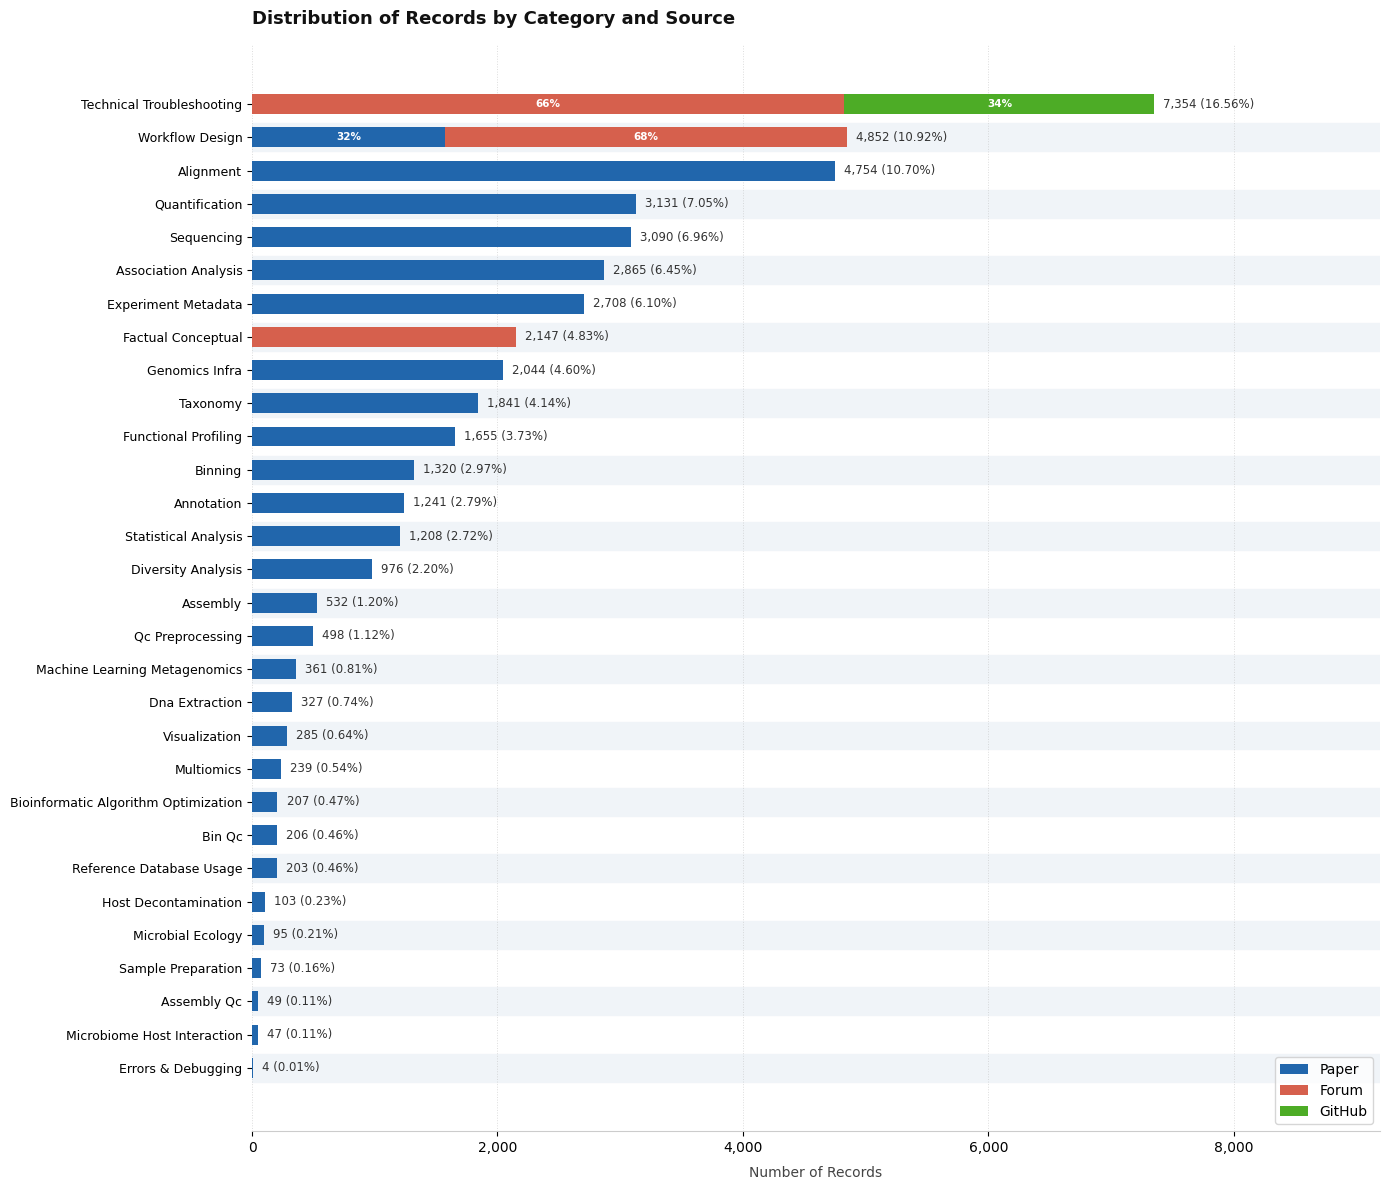

Total categories : 30
Total records    : 44,415


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from collections import defaultdict, Counter

# 1. Chargement de GitHub (s'il n'est pas déjà chargé dans la mémoire de Jupyter)
if 'github_rows' not in locals():
    github_rows = load_jsonl(GITHUB_FILE)

# 2. Règles de fusion
CATEGORY_MERGE = {
   # "errors_&_debugging": "technical_troubleshooting",
    "machine_learning": "machine_learning_metagenomics",
    "pipeline_design"               : "workflow_design",
}

# 3. Comptage séparé par source (Paper, Forum, Github)
cat_counts = defaultdict(lambda: {'paper': 0, 'forum': 0, 'github': 0})

# A. Traitement des Papers (avec la règle stricte pour le workflow)
for r in paper_rows:
    t = str(r.get("type", "")).strip().lower()
    if t == "workflow":
        c = "workflow_design"
    else:
        c = str(r.get("category", "")).strip().lower()
        c = CATEGORY_MERGE.get(c, c)
    
    # On ignore "factual" et "conceptual" mais on garde "factual_conceptual"
    if c and c not in ["factual", "conceptual"]:
        cat_counts[c]['paper'] += 1

# B. Traitement des Forums
for r in forum_rows:
    meta = r.get("metadata", {})
    c = meta.get("category", "") if isinstance(meta, dict) else ""
    c = c.strip().lower()
    c = CATEGORY_MERGE.get(c, c)
    
    if c and c not in ["factual", "conceptual"]:
        cat_counts[c]['forum'] += 1

# C. Traitement de GitHub
for r in github_rows:
    meta = r.get("metadata", {})
    c = meta.get("category", r.get("category", "")) if isinstance(meta, dict) else r.get("category", "")
    c = c.strip().lower()
    c = CATEGORY_MERGE.get(c, c)
    
    if c and c not in ["factual", "conceptual"]:
        cat_counts[c]['github'] += 1

# 4. Préparation et tri des données
cat_totals = {c: counts['paper'] + counts['forum'] + counts['github'] for c, counts in cat_counts.items()}
cat_totals = {c: v for c, v in cat_totals.items() if v > 0}
cat_sorted = sorted(cat_totals.items(), key=lambda x: x[1], reverse=True)

# Inversion pour avoir la plus grande barre en haut
cat_labels = [c.replace("_", " ").title() for c, _ in cat_sorted][::-1]
paper_vals = [cat_counts[c]['paper'] for c, _ in cat_sorted][::-1]
forum_vals = [cat_counts[c]['forum'] for c, _ in cat_sorted][::-1]
github_vals = [cat_counts[c]['github'] for c, _ in cat_sorted][::-1]
total_vals = [v for _, v in cat_sorted][::-1]

n = len(cat_sorted)
total_all = sum(total_vals)

# 5. Création du graphique (Stacked Bar Chart)
fig, ax = plt.subplots(figsize=(14, max(8, n * 0.4)))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Bandes grises de fond pour la lisibilité
for i in range(n):
    if i % 2 == 0:
        ax.axhspan(i - 0.42, i + 0.42, color='#F0F4F8', zorder=0)

y_pos = np.arange(n)

# Couleurs pour les 3 sources
COLOR_PAPER  = '#2166AC'  # Bleu
COLOR_FORUM  = '#D6604D'  # Rouge
COLOR_GITHUB = '#4DAC26'  # Vert

# Dessin des barres empilées
bars_paper = ax.barh(y_pos, paper_vals, color=COLOR_PAPER, height=0.6, zorder=2, label='Paper')
bars_forum = ax.barh(y_pos, forum_vals, left=paper_vals, color=COLOR_FORUM, height=0.6, zorder=2, label='Forum')

left_github = [p + f for p, f in zip(paper_vals, forum_vals)]
bars_github = ax.barh(y_pos, github_vals, left=left_github, color=COLOR_GITHUB, height=0.6, zorder=2, label='GitHub')

ax.set_yticks(y_pos)
ax.set_yticklabels(cat_labels)

# 6. Affichage des pourcentages UNIQUEMENT pour les catégories combinées
for i in range(n):
    p_val = paper_vals[i]
    f_val = forum_vals[i]
    g_val = github_vals[i]
    tot = total_vals[i]
    
    # On compte combien de sources ont des données pour cette catégorie
    active_sources = (p_val > 0) + (f_val > 0) + (g_val > 0)
    
    # Si la catégorie combine PLUSIEURS sources, on affiche les % internes
    if active_sources > 1:
        if p_val > 0 and (p_val / tot * 100) > 4:  # > 4% pour que le texte rentre
            x = bars_paper[i].get_x() + bars_paper[i].get_width() / 2
            y = bars_paper[i].get_y() + bars_paper[i].get_height() / 2
            ax.text(x, y, f'{p_val/tot*100:.0f}%', ha='center', va='center', color='white', fontsize=7.5, fontweight='bold')
            
        if f_val > 0 and (f_val / tot * 100) > 4:
            x = bars_forum[i].get_x() + bars_forum[i].get_width() / 2
            y = bars_forum[i].get_y() + bars_forum[i].get_height() / 2
            ax.text(x, y, f'{f_val/tot*100:.0f}%', ha='center', va='center', color='white', fontsize=7.5, fontweight='bold')
            
        if g_val > 0 and (g_val / tot * 100) > 4:
            x = bars_github[i].get_x() + bars_github[i].get_width() / 2
            y = bars_github[i].get_y() + bars_github[i].get_height() / 2
            ax.text(x, y, f'{g_val/tot*100:.0f}%', ha='center', va='center', color='white', fontsize=7.5, fontweight='bold')

# Ajout du Total et du % global à l'extrémité de chaque barre
max_val = max(total_vals) if total_vals else 1                 
for i, t_val in enumerate(total_vals):

    overall_pct = t_val / total_all * 100
    ax.text(t_val + (max_val * 0.01), i,
            f'{t_val:,} ({overall_pct:.2f}%)',
            va='center', ha='left', fontsize=8.5, color='#333333')
    

ax.set_xlabel('Number of Records', labelpad=8, fontsize=10, color='#444444')
ax.set_title('Distribution of Records by Category and Source',
             fontsize=13, fontweight='bold', pad=15, color='#111111', loc='left')
ax.set_xlim(0, max_val * 1.25)
ax.tick_params(axis='y', labelsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', linestyle=':', linewidth=0.7, alpha=0.5, color='#BBBBBB', zorder=1)
ax.spines['bottom'].set_color('#CCCCCC')

# Légende
ax.legend(loc='lower right', frameon=True, fontsize=10, facecolor='white', edgecolor='#CCCCCC')

plt.tight_layout()
plt.savefig('fig2_category_distribution_sources.pdf')
plt.savefig('fig2_category_distribution_sources.png')
plt.show()

print(f"Total categories : {n}")
print(f"Total records    : {total_all:,}")

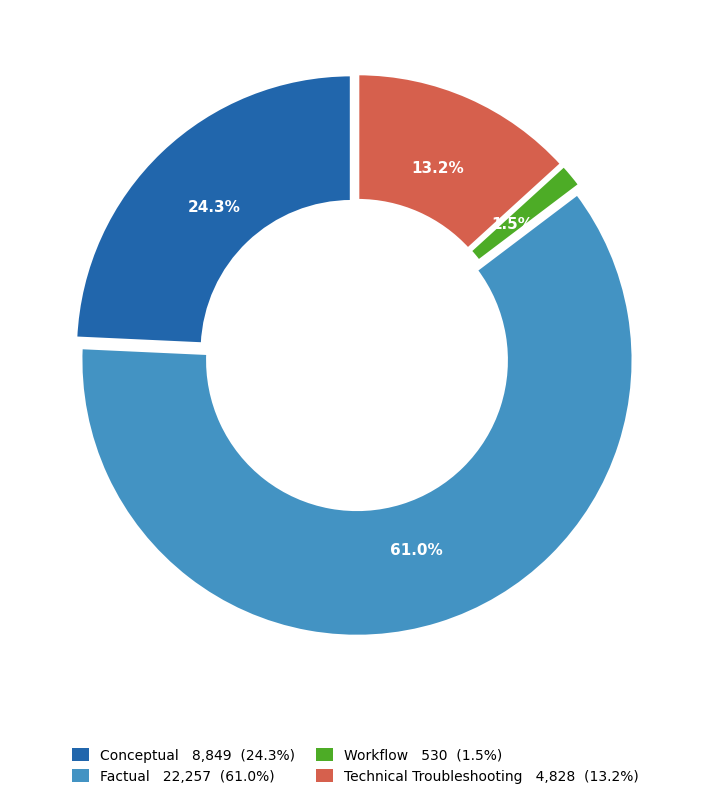

Conceptual                     : 8,849 (24.3%)
Factual                        : 22,257 (61.0%)
Workflow                       : 530 (1.5%)
Technical Troubleshooting      : 4,828 (13.2%)


In [11]:
def get_type_4(row, source):
    if source == "paper":
        t = str(row.get("type", "")).strip().lower()
        if t == "workflow":
            return "Workflow"
        elif t == "factual":
            return "Factual"
        else:
            return "Conceptual"
    elif source == "forum":
        meta = row.get("metadata")
        cat  = meta.get("category", "") if isinstance(meta, dict) else ""
        cat  = cat.strip().lower()
        if cat in ("technical_troubleshooting", "errors_&_debugging", "troubleshooting"):
            return "Technical Troubleshooting"
        else:
            return None
    elif source == "github":
        # GitHub : category directement dans le row
        cat = str(row.get("category", "")).strip().lower()
        if cat in ("technical_troubleshooting", "errors_&_debugging", "troubleshooting"):
            return "Technical Troubleshooting"
        else:
            return None

counter4 = Counter()
for r in paper_rows:
    counter4[get_type_4(r, "paper")] += 1
for r in forum_rows:
    t = get_type_4(r, "forum")
    if t:
        counter4[t] += 1
for r in github_rows:
    t = get_type_4(r, "github")
    if t:
        counter4[t] += 1

order4  = ["Conceptual", "Factual", "Workflow", "Technical Troubleshooting"]
order4  = [t for t in order4 if t in counter4]
vals4   = [counter4[t] for t in order4]
total4  = sum(vals4)

COLORS4 = {
    "Conceptual"               : "#2166AC",
    "Factual"                  : "#4393C3",
    "Workflow"                 : "#4DAC26",
    "Technical Troubleshooting": "#D6604D",
}

fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

wedges, _, autotexts = ax.pie(
    vals4,
    labels=None,
    colors=[COLORS4[t] for t in order4],
    autopct=lambda p: f'{p:.1f}%',
    pctdistance=0.72,
    startangle=90,
    wedgeprops=dict(width=0.46, edgecolor='white', linewidth=2.5),
    explode=[0.02] * len(order4),
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
    at.set_fontsize(11)

patches = [
    mpatches.Patch(
        facecolor=COLORS4[t],
        edgecolor='none',
        label=f'{t}   {counter4[t]:,}  ({counter4[t]/total4*100:.1f}%)'
    )
    for t in order4
]
ax.legend(
    handles=patches,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.14),
    ncol=2,
    frameon=False,
    fontsize=10,
    handlelength=1.2,
    handleheight=1.0,
    borderpad=0.5,
    columnspacing=1.5,
)


ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('fig_type_pie4.pdf')
plt.savefig('C:/Users/PC/Downloads/genomeer/images_VF/fig_type_pie4.png', dpi=600)
plt.show()

for t in order4:
    print(f"{t:<30} : {counter4[t]:,} ({counter4[t]/total4*100:.1f}%)")

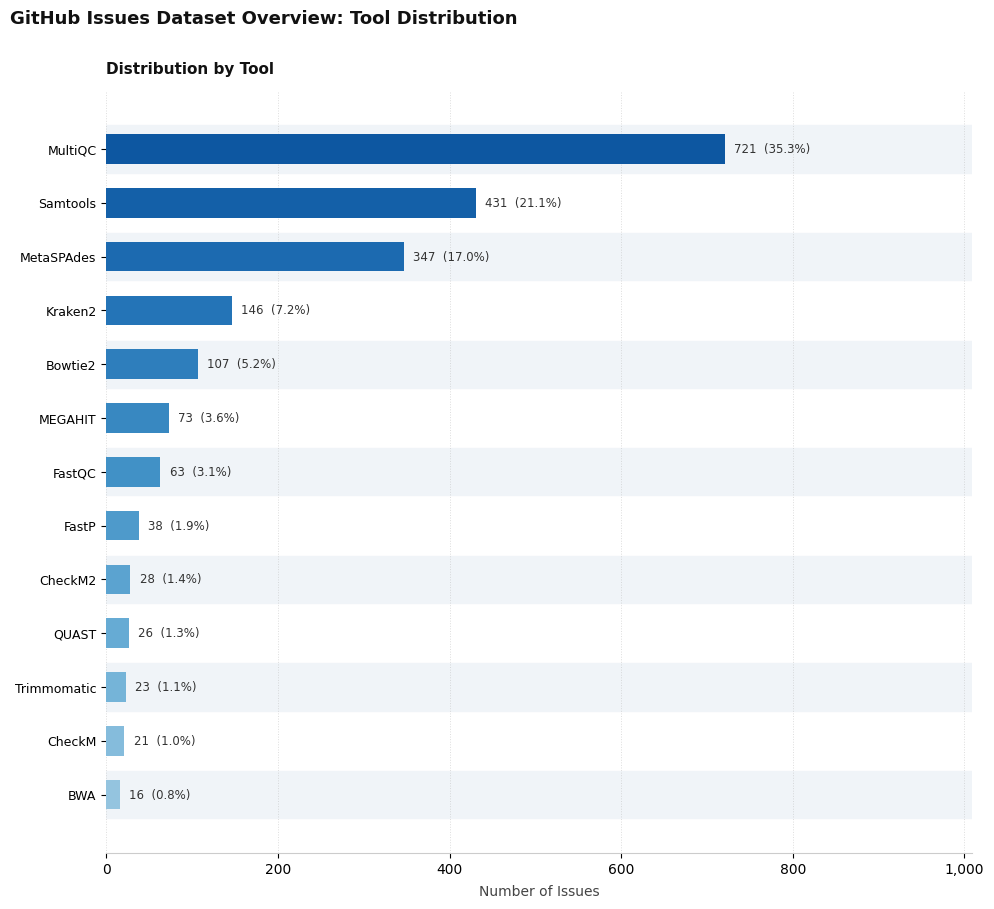


Total issues (with output): 2,040
  MultiQC                   : 721 (35.3%)
  Samtools                  : 431 (21.1%)
  MetaSPAdes                : 347 (17.0%)
  Kraken2                   : 146 (7.2%)
  Bowtie2                   : 107 (5.2%)
  MEGAHIT                   : 73 (3.6%)
  FastQC                    : 63 (3.1%)
  FastP                     : 38 (1.9%)
  CheckM2                   : 28 (1.4%)
  QUAST                     : 26 (1.3%)
  Trimmomatic               : 23 (1.1%)
  CheckM                    : 21 (1.0%)
  BWA                       : 16 (0.8%)


In [12]:
import json
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


github_rows = []
with open("C:/Users/PC/Downloads/genomeer/dataset_llm_vf.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            github_rows.append(json.loads(line))

# ── Extract tool ──
tool_counter = Counter()

for r in github_rows:
    if not r.get("output", "").strip():
        continue
    meta = r.get("metadata")
    tool = meta.get("tool", "Unknown") if isinstance(meta, dict) else "Unknown"
    tool_counter[tool] += 1

# ── Top 20 ──
TOP_TOOLS = 20
top_tools = tool_counter.most_common(TOP_TOOLS)
tools, tool_vals = zip(*top_tools)
total_tools = sum(tool_vals)

# ── Style ──
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 10,
    'axes.linewidth'   : 0.8,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.spines.left' : False,
    'savefig.dpi'      : 600,
    'savefig.bbox'     : 'tight',
    'savefig.facecolor': 'white',
})

fig, ax = plt.subplots(figsize=(10, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

n_tools     = len(tools)
cmap_tool   = plt.cm.Blues
colors_tool = [cmap_tool(0.85 - 0.45 * i / max(n_tools - 1, 1)) for i in range(n_tools)]

for i in range(n_tools):
    if i % 2 == 0:
        ax.axhspan(i - 0.44, i + 0.44, color='#F0F4F8', zorder=0)

bars = ax.barh(
    list(tools)[::-1], list(tool_vals)[::-1],
    color=colors_tool[::-1],
    height=0.55, edgecolor='none', zorder=2
)
for bar, val in zip(bars, list(tool_vals)[::-1]):
    pct = val / total_tools * 100
    ax.text(
        bar.get_width() + max(tool_vals) * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}  ({pct:.1f}%)',
        va='center', ha='left', fontsize=8.5, color='#333333'
    )

ax.set_title('Distribution by Tool',
             fontsize=11, fontweight='bold', pad=12, color='#111111', loc='left')
ax.set_xlabel('Number of Issues', labelpad=6, fontsize=10, color='#444444')
ax.set_xlim(0, max(tool_vals) * 1.40)
ax.tick_params(axis='y', labelsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', linestyle=':', linewidth=0.7, alpha=0.5, color='#BBBBBB', zorder=1)
ax.spines['bottom'].set_color('#CCCCCC')

fig.suptitle(
    'GitHub Issues Dataset Overview: Tool Distribution',
    fontsize=13, fontweight='bold', color='#111111', y=1.005, x=0.01, ha='left'
)

plt.tight_layout()
#plt.savefig('fig_github_tools_only.pdf')
plt.savefig('C:/Users/PC/Downloads/genomeer/images_VF/fig_github_tools_only.png', dpi=600)
plt.show()

print(f"\nTotal issues (with output): {total_tools:,}")
for t, v in top_tools:
    print(f"  {t:<25} : {v:,} ({v/total_tools*100:.1f}%)")